# Flood · Wind-farm — M3 damage: greenfield flood-depth → per-node damage, all three sub-perils

**Magnitude metric:** inundation **depth (ft above ground)** per node — riverine/pluvial by return period (annual-max
frame), coastal surge by hurricane category (per storm, `event_family_id`-stamped) — the depth→damage curve's x-axis.
**Data source:** the M2 per-node depth tables (riverine + pluvial + coastal), the M0 site/TIV record
(`flood_wind_m0_sites.json`), and a greenfield flood × wind depth-damage curve built here and vendored to
`data/flood/damage_curves/` — capex weights from the convective_wind `wind_config` (rotor 0.26 · nacelle 0.21 ·
tower 0.16 · foundation 0.12 · substation 0.09 · electrical 0.09 · civil 0.07), curve shapes borrowed from the
infrasure-damage-curves flood × solar library (down-tower electrical ≈ inverter x0 0.75 ft; substation x0 1.5 ft;
civil x0 2 ft) plus a foundation-scour curve by judgment; low–medium confidence.
**What this notebook does:** maps each M2 per-node depth → a capex-weighted damage ratio, then sums loss over the
flooded turbines + the shared substation: `loss = Σ_i (T/N)·Σ_s wₛ·DRₛ(dᵢ) + w_sub·T·DR_sub(d_sub)`. **One
source-agnostic curve serves all three sub-perils — inundation is inundation** (the equipment doesn't care whether
the water came from river, sky, or sea). The flood-specific physics is the height inversion at its limit:
rotor/nacelle/tower are **flood-immune** (nacelle ~80–140 m up, sealed steel tower → DR = 0, 0.63 of value); only
the **base** is vulnerable (~0.37): foundation (scour/saturation), down-tower electrical, civil (pads/roads), and the
substation. Output is per-storm/per-RP conditional losses M4 combines —
riverine+pluvial worse-source-wins ([JD-FL-11](../../../../docs/plans/flood/decisions.md)), coastal joined to
hurricane wind per storm ([JD-FL-12](../../../../docs/plans/flood/decisions.md)).

> Plan: [`m_wind_farm.md`](../../../../docs/plans/flood/m_wind_farm.md) · Solar curve source:
> [`flood/solar/m3_damage/01`](../../../solar/m3_damage/01_damage.ipynb).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"
FT_M = 0.3048

SUBPERILS = {
    "riverine": {"depths": "flood_wind_riverine_m2_depths"},  # Path 2: per-node depths from M2 (JD-FL-19) — M3 reads M2, not M1
    "pluvial":  {"depths": "flood_wind_pluvial_m2_depths"},   # Path 2: per-node ponding from M2 (JD-FL-19)
}
sites = {s["slug"]: {**s, "tiv_usd": s["tiv"]} for s in json.loads((OUT / "flood_wind_m0_sites.json").read_text())["sites"]}   # site info from M0 (tiv→tiv_usd)
_any = next(iter(sites))   # RPs are defined by M2's depth columns (depth_<rp>_m), not by M1 (Path 2)
RPS = {sp: sorted(int(c[6:-2]) for c in pd.read_parquet(OUT / f"{_any}_{cfg['depths']}.parquet").columns
                  if c.startswith("depth_") and c.endswith("_m"))
       for sp, cfg in SUBPERILS.items()}
print("sites:", {sl: f"{s['name']} (TIV ${s['tiv_usd']/1e6:.0f}M, {s['n_turb']} turb)" for sl, s in sites.items()})
print("sub-perils × RPs:", {sp: RPS[sp] for sp in SUBPERILS})

sites: {'green_river_il': 'Green River (TIV $272M, 74 turb)', 'shepherds_flat_or': 'Shepherds Flat (TIV $1183M, 384 turb)', 'amazon_wind_us_east': 'Amazon Wind Farm US East (TIV $291M, 104 turb)'}
sub-perils × RPs: {'riverine': [10, 25, 50, 100, 250, 500], 'pluvial': [10, 25, 50, 100, 500]}


## 1 · The capex split — flood-immune top, vulnerable base (greenfield, the old-repo wind_config)

One turbine's value splits rotor/nacelle/tower/foundation/electrical/civil = **0.91**; the shared **substation** =
**0.09**. Flood reaches only the **base**: foundation + down-tower electrical + civil (**0.28** of the turbine) + the
substation (**0.09**) = **0.37** of farm value. The elevated rotor/nacelle/tower (**0.63**) are **immune** (DR 0).

In [2]:
CAPEX = {"rotor_blades": 0.26, "nacelle_drivetrain": 0.21, "tower": 0.16,        # FLOOD-IMMUNE (elevated) → 0.63
         "foundation": 0.12, "electrical": 0.09, "civil": 0.07,                  # per-turbine vulnerable base → 0.28
         "substation": 0.09}                                                     # shared node, vulnerable → 0.09
IMMUNE = ["rotor_blades", "nacelle_drivetrain", "tower"]
TURB_VULN = ["foundation", "electrical", "civil"]   # per-turbine vulnerable subsystems
assert abs(sum(CAPEX.values()) - 1.0) < 1e-9

# vulnerable depth-damage curves (ft above grade): borrowed from flood×solar library + foundation by judgment
#   subsystem : (L, k, x0_ft, source)
CURVES = {
    "electrical":  (0.90, 3.0, 0.75, "≈ solar inverter curve (down-tower switchgear drowns shallow)"),
    "substation":  (0.95, 2.5, 1.50, "≈ solar substation curve (collector transformer/switchgear)"),
    "civil":       (0.70, 1.2, 2.00, "≈ solar civil_infra curve (pad/road scour)"),
    "foundation":  (0.40, 0.8, 3.00, "judgment: massive RC pier — only deep/sustained flood scours/saturates it"),
}


def dr(depth_ft, L, k, x0):
    raw = L / (1 + np.exp(-k * (depth_ft - x0)))
    floor = L / (1 + np.exp(-k * (0 - x0)))
    return float(np.clip(raw - floor, 0, None))     # anchored DR(0)=0


def turbine_loss_frac(depth_ft):
    """Loss as a fraction of ONE turbine's full value share (T/N): Σ over vulnerable subsystems wₛ·DRₛ."""
    return sum(CAPEX[s] * dr(depth_ft, *CURVES[s][:3]) for s in TURB_VULN)


def substation_loss_frac(depth_ft):
    """Loss as a fraction of farm TIV from the substation node: w_sub·DR_sub."""
    return CAPEX["substation"] * dr(depth_ft, *CURVES["substation"][:3])


print(f"capex sum = {sum(CAPEX.values()):.2f} | immune (rotor+nacelle+tower) = {sum(CAPEX[s] for s in IMMUNE):.2f} | "
      f"vulnerable base = {sum(CAPEX[s] for s in TURB_VULN) + CAPEX['substation']:.2f}")
print("vulnerable curves (depth_ft → DR):")
for s, (L, k, x0, src) in CURVES.items():
    print(f"  {s:11s} L={L} k={k} x0={x0}ft  — {src}")

capex sum = 1.00 | immune (rotor+nacelle+tower) = 0.63 | vulnerable base = 0.37
vulnerable curves (depth_ft → DR):
  electrical  L=0.9 k=3.0 x0=0.75ft  — ≈ solar inverter curve (down-tower switchgear drowns shallow)
  substation  L=0.95 k=2.5 x0=1.5ft  — ≈ solar substation curve (collector transformer/switchgear)
  civil       L=0.7 k=1.2 x0=2.0ft  — ≈ solar civil_infra curve (pad/road scour)
  foundation  L=0.4 k=0.8 x0=3.0ft  — judgment: massive RC pier — only deep/sustained flood scours/saturates it


## 2 · The two node curves — turbine (base only) vs substation

A fully-flooded **turbine** can lose only its vulnerable base (~0.28 of its value), because rotor/nacelle/tower
(0.63) are immune. A flooded **substation** loses most of its value (transformer/switchgear at grade).

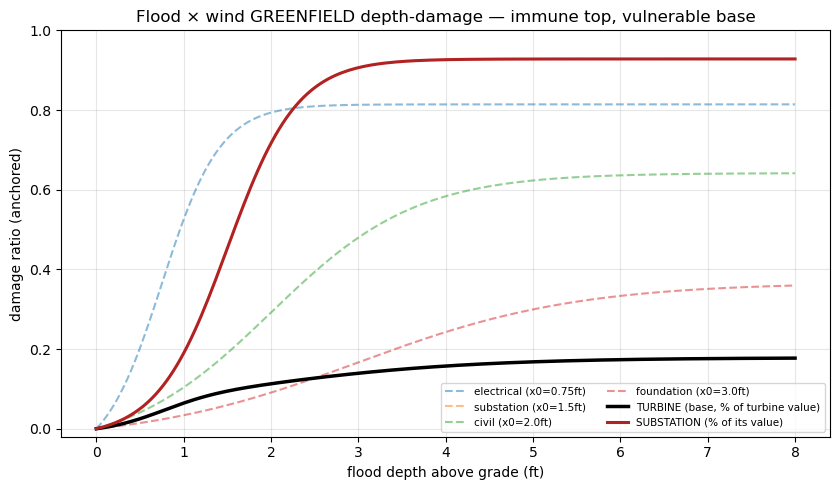

In [3]:
import matplotlib.pyplot as plt

xs = np.linspace(0, 8, 200)
fig, ax = plt.subplots(figsize=(8.5, 5))
for s, (L, k, x0, _) in CURVES.items():
    ax.plot(xs, [dr(x, L, k, x0) for x in xs], "--", alpha=0.5, label=f"{s} (x0={x0}ft)")
ax.plot(xs, [turbine_loss_frac(x) / sum(CAPEX[v] for v in (IMMUNE + TURB_VULN)) for x in xs], "k-", lw=2.5,
        label="TURBINE (base, % of turbine value)")
ax.plot(xs, [dr(x, *CURVES["substation"][:3]) for x in xs], color="firebrick", lw=2.2, label="SUBSTATION (% of its value)")
ax.set_xlabel("flood depth above grade (ft)"); ax.set_ylabel("damage ratio (anchored)")
ax.set_title("Flood × wind GREENFIELD depth-damage — immune top, vulnerable base")
ax.legend(fontsize=7.5, ncol=2); ax.grid(alpha=0.3); ax.set_ylim(-0.02, 1.0)
fig.tight_layout()
plt.show()

## 3 · Conditional loss per sub-peril × site × return period (sum over flooded turbines + substation)

`loss_frac(sp, RP) = (1/N)·Σ_i turbine_loss_frac(dᵢ) + substation_loss_frac(d_sub)` — the per-node sum, as a
fraction of farm TIV, run once per sub-peril over its own per-node depth table.

In [4]:
rows = []
for sp, cfg in SUBPERILS.items():
    for slug, s in sites.items():
        nodes = pd.read_parquet(OUT / f"{slug}_{cfg['depths']}.parquet")
        t = nodes[nodes.kind == "turbine"]; sub = nodes[nodes.kind == "substation"].iloc[0]
        N = len(t); TIV = s["tiv_usd"]
        for rp in RPS[sp]:
            d_t = t[f"depth_{rp}_m"].values / FT_M          # m → ft
            d_sub = sub[f"depth_{rp}_m"] / FT_M
            turb_frac = float(np.mean([turbine_loss_frac(d) for d in d_t]))   # (1/N)·Σ turbine_loss_frac
            sub_frac = substation_loss_frac(d_sub)
            loss_frac = turb_frac + sub_frac
            rows.append({"sub_peril": sp, "slug": slug, "name": s["name"], "role": s["role"], "rp_years": rp,
                         "tiv_usd": TIV, "n_flooded": int((t[f"depth_{rp}_m"] > 0).sum()),
                         "turb_loss_frac_tiv": round(turb_frac, 5), "sub_loss_frac_tiv": round(sub_frac, 5),
                         "cond_loss_frac_tiv": round(loss_frac, 5), "cond_loss_usd": round(loss_frac * TIV)})
dmg = pd.DataFrame(rows)
print(dmg[["sub_peril", "name", "rp_years", "n_flooded", "turb_loss_frac_tiv", "sub_loss_frac_tiv",
           "cond_loss_frac_tiv", "cond_loss_usd"]].to_string(index=False))

sub_peril                     name  rp_years  n_flooded  turb_loss_frac_tiv  sub_loss_frac_tiv  cond_loss_frac_tiv  cond_loss_usd
 riverine              Green River        10         17             0.01850            0.05752             0.07601       20666105
 riverine              Green River        25         19             0.02303            0.07472             0.09775       26576917
 riverine              Green River        50         20             0.02575            0.07912             0.10487       28511640
 riverine              Green River       100         22             0.02789            0.08105             0.10894       29618719
 riverine              Green River       250         23             0.03020            0.08215             0.11235       30546044
 riverine              Green River       500         24             0.03159            0.08256             0.11414       31033464
 riverine           Shepherds Flat        10          0             0.00000            0.0

## 3b · Coastal — per-storm conditional loss (event-based), same source-agnostic curve

Coastal depths are per-node **by hurricane category** (M2). Apply the same curve per node → a loss fraction **per
category**, then map each qualifying storm (its near-site category) → its loss, tagged `event_family_id`. Output is
**per-storm** (the compound-Poisson input M4 joins to hurricane wind), not per-RP.

In [5]:
cman = json.loads((OUT / "flood_coastal_m1_catalog_manifest.json").read_text())
coastal_sites = [c for c in cman["sites"] if c["asset"] == "wind_farm" and c["exposed"]]
coa_rows, loss_ladders = [], {}
for cs in coastal_sites:
    cslug = cs["slug"]; s = sites[cslug]; TIV = s["tiv_usd"]
    nd = pd.read_parquet(OUT / f"{cslug}_flood_wind_coastal_m2_node_depths.parquet")
    t = nd[nd.kind == "turbine"]; sub = nd[nd.kind == "substation"].iloc[0]
    loss_by_cat = {}
    for c in range(1, 6):
        d_t = t[f"depth_cat{c}_m"].values / FT_M; d_sub = sub[f"depth_cat{c}_m"] / FT_M
        tf = float(np.mean([turbine_loss_frac(d) for d in d_t])); sf = substation_loss_frac(d_sub)
        loss_by_cat[c] = {"turb_loss_frac_tiv": tf, "sub_loss_frac_tiv": sf, "cond_loss_frac_tiv": tf + sf}
    loss_ladders[cslug] = loss_by_cat
    storms = pd.read_parquet(OUT / f"{cslug}_flood_wind_coastal_m2_coupling.parquet")
    for r in storms.itertuples():
        lb = loss_by_cat.get(int(r.category), {"turb_loss_frac_tiv": 0.0, "sub_loss_frac_tiv": 0.0, "cond_loss_frac_tiv": 0.0})
        coa_rows.append({"sub_peril": "coastal", "slug": cslug, "name": s["name"], "role": s["role"],
                         "storm_ID": int(r.storm_ID), "event_family_id": int(r.event_family_id), "category": int(r.category),
                         "tiv_usd": TIV, "n_flooded": int(r.n_flooded), **{k: round(v, 5) for k, v in lb.items()},
                         "cond_loss_usd": round(lb["cond_loss_frac_tiv"] * TIV)})
coa_dmg = pd.DataFrame(coa_rows)
if len(coa_dmg):
    print("\ncoastal per-category loss ladder (% of TIV):")
    for cslug, lbc in loss_ladders.items():
        nm = sites[cslug]["name"]
        for c in range(1, 6):
            print(f"  {nm:24s} Cat{c}: {lbc[c]['cond_loss_frac_tiv']*100:5.2f}% "
                  f"(turb {lbc[c]['turb_loss_frac_tiv']*100:.2f}% + sub {lbc[c]['sub_loss_frac_tiv']*100:.2f}%)")
    print(f"  {coa_dmg['name'].iloc[0]}: {len(coa_dmg)} storms, worst {coa_dmg['cond_loss_frac_tiv'].max()*100:.2f}% of TIV")


coastal per-category loss ladder (% of TIV):
  Amazon Wind Farm US East Cat1:  0.00% (turb 0.00% + sub 0.00%)
  Amazon Wind Farm US East Cat2:  0.00% (turb 0.00% + sub 0.00%)
  Amazon Wind Farm US East Cat3:  5.98% (turb 4.25% + sub 1.73%)
  Amazon Wind Farm US East Cat4: 19.33% (turb 11.00% + sub 8.34%)
  Amazon Wind Farm US East Cat5: 23.22% (turb 14.86% + sub 8.35%)
  Amazon Wind Farm US East: 24 storms, worst 5.98% of TIV


## 4 · Known-answer checks (basics-spot-on)

- **Anchored:** `DR(0)=0`. **Immune top:** even at 10 ft the turbine DR ≤ ~0.28 (rotor/nacelle/tower never damage).
- **Inversion:** electrical (x0 0.75) drowns before substation (1.5) before civil (2) before foundation (3).
- **Riverine** Green River grows 100→500yr and ≫ the dry baseline. **Pluvial** is far smaller — with f+d_cap
  lidar-grounded (JD-FL-15) every node is pad-shed → pluvial conditional loss = **0** (water-limited floor).

In [6]:
assert abs(turbine_loss_frac(0.0)) < 1e-9 and abs(substation_loss_frac(0.0)) < 1e-9, "DR(0) must be 0 (anchored)"
turb_full = turbine_loss_frac(10.0) / sum(CAPEX[v] for v in (IMMUNE + TURB_VULN))
assert turb_full <= 0.30, "a flooded turbine must lose ≤~28% (rotor/nacelle/tower immune)"
assert dr(1.0, *CURVES["electrical"][:3]) > dr(1.0, *CURVES["foundation"][:3]), "electrical drowns before foundation"
riv = dmg[dmg.sub_peril == "riverine"]; pluv = dmg[dmg.sub_peril == "pluvial"]
gr = riv[riv.slug == "green_river_il"].set_index("rp_years")
sf = riv[riv.slug == "shepherds_flat_or"].set_index("rp_years")
assert gr.loc[500, "cond_loss_frac_tiv"] >= gr.loc[100, "cond_loss_frac_tiv"] > 0, "Green River riverine loss should grow 100→500yr"
assert sf.loc[500, "cond_loss_frac_tiv"] == 0, "riverine baseline loss must be 0 (dry)"
grp = pluv[pluv.slug == "green_river_il"].set_index("rp_years")
assert (grp["turb_loss_frac_tiv"] == 0).all(), "pluvial turbine loss should be 0 (pad-gated dry)"
assert grp.loc[500, "cond_loss_frac_tiv"] < gr.loc[500, "cond_loss_frac_tiv"], "pluvial loss < riverine (smaller peril for wind)"
print(f"✓ anchored DR(0)=0 | a fully-flooded turbine loses {turb_full*100:.0f}% (≤28%, top immune)")
print(f"✓ inversion: electrical drowns before foundation (DR@1ft: elec {dr(1,*CURVES['electrical'][:3]):.2f} > found {dr(1,*CURVES['foundation'][:3]):.2f})")
print(f"✓ RIVERINE Green River: 100yr {gr.loc[100,'cond_loss_frac_tiv']*100:.2f}% → 500yr {gr.loc[500,'cond_loss_frac_tiv']*100:.2f}% of TIV "
      f"(turbines {gr.loc[500,'turb_loss_frac_tiv']*100:.2f}% + substation {gr.loc[500,'sub_loss_frac_tiv']*100:.2f}%); baseline 0%")
print(f"✓ PLUVIAL Green River: 0% at every node/RP (lidar-grounded floor, water-limited; JD-FL-15); 500yr {grp.loc[500,'cond_loss_frac_tiv']*100:.3f}% of TIV "
      f"≪ riverine — the smaller peril")
if len(coa_dmg):
    aw = next(iter(loss_ladders)); lad = loss_ladders[aw]
    cats = sorted(int(c) for c in coa_dmg["category"].unique())
    assert all(lad[c]["cond_loss_frac_tiv"] <= lad[c+1]["cond_loss_frac_tiv"] for c in range(1, 5)), "coastal loss must rise with category"
    assert coa_dmg["cond_loss_frac_tiv"].max() > 0, "an exposed coastal site must have a storm with >0 loss"
    print(f"✓ COASTAL {sites[aw]['name']}: loss rises with category (Cat3 {lad[3]['cond_loss_frac_tiv']*100:.2f}% → "
          f"Cat5 {lad[5]['cond_loss_frac_tiv']*100:.2f}% of TIV); {len(coa_dmg)} storms, cats present {cats}")
print("✓ M3 known-answer checks pass (riverine + pluvial + coastal).")

✓ anchored DR(0)=0 | a fully-flooded turbine loses 18% (≤28%, top immune)
✓ inversion: electrical drowns before foundation (DR@1ft: elec 0.53 > found 0.03)
✓ RIVERINE Green River: 100yr 10.89% → 500yr 11.41% of TIV (turbines 3.16% + substation 8.26%); baseline 0%
✓ PLUVIAL Green River: 0% at every node/RP (lidar-grounded floor, water-limited; JD-FL-15); 500yr 0.000% of TIV ≪ riverine — the smaller peril
✓ COASTAL Amazon Wind Farm US East: loss rises with category (Cat3 5.98% → Cat5 23.22% of TIV); 24 storms, cats present [1, 2, 3]
✓ M3 known-answer checks pass (riverine + pluvial + coastal).


## 5 · Vendor the greenfield curve + persist the M3 manifest

The vendored curve is **sub-peril-agnostic** (inundation depth → damage, regardless of source). The manifest carries
both sub-perils' conditional losses for M4 to combine.

In [7]:
(OUT / "damage_curves").mkdir(parents=True, exist_ok=True)
vendored = {
    "curve_id": "flood/wind__asset__capex_weighted", "hazard_type": "FLOOD", "asset_type": "wind",
    "applies_to_sub_perils": ["riverine", "pluvial", "coastal"], "note": "source-agnostic — inundation depth → damage (river, sky, or sea)",
    "status": "GREENFIELD (no flood×wind curve in infrasure-damage-curves) — graduates to the library later",
    "confidence": "low-medium", "intensity_metric": "flood_depth_ft", "intensity_unit": "ft",
    "logistic_form": "DR(x) = L/(1+exp(-k(x-x0))) anchored so DR(0)=0",
    "capex_weights": CAPEX,
    "flood_immune": {s: CAPEX[s] for s in IMMUNE},
    "vulnerable_curves": {s: {"L": L, "k": k, "x0_ft": x0, "source": src} for s, (L, k, x0, src) in CURVES.items()},
    "node_model": {
        "turbine_value": "0.91·TIV/N each (rotor+nacelle+tower immune; foundation+electrical+civil vulnerable)",
        "substation_value": "0.09·TIV (single shared collector node, vulnerable)",
        "loss_rule": "loss = (1/N)·Σ_i Σ_s∈{found,elec,civil} wₛ·DRₛ(dᵢ)·TIV + w_sub·DR_sub(d_sub)·TIV",
    },
    "metadata": {
        "capex_source": "old-repo wind_config / convective_wind (rotor .26 nacelle .21 tower .16 found .12 sub .09 elec .09 civil .07)",
        "shapes_borrowed_from": "infrasure-damage-curves RIVERINE_FLOOD × solar (inverter→electrical, substation, civil)",
        "foundation_curve": "by judgment (massive RC; high threshold, shallow slope)",
        "physics": "height inversion at the limit — rotor/nacelle/tower elevated → flood-immune; only the base floods",
    },
}
(OUT / "damage_curves" / "flood_wind_asset_capex_weighted.json").write_text(json.dumps(vendored, indent=2))
manifest = {
    "peril": "flood", "sub_peril": ["riverine", "pluvial", "coastal"], "event_family_id": None, "layer": "M3", "asset": "wind_farm",
    "curve": "GREENFIELD flood × wind capex-weighted per-node (low-medium confidence) — source-agnostic, all three sub-perils",
    "conditional_loss_rule": "Σ over flooded turbines (base subsystems) + shared substation",
    "combine_at_M4": "riverine + pluvial co-sampled comonotonic worse-source-wins headline (JD-FL-11); coastal joined to hurricane wind per event_family_id (JD-FL-12)",
    "rp_rows": json.loads(dmg.to_json(orient="records")),                          # riverine + pluvial (RP-indexed)
    "coastal_event_rows": json.loads(coa_dmg.to_json(orient="records")) if len(coa_dmg) else [],   # coastal (per-storm)
    "sites": json.loads(dmg.to_json(orient="records")),                            # back-compat alias (= rp_rows)
}
(OUT / "flood_wind_m3_damage_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "damage_curves" / "flood_wind_asset_capex_weighted.json")
print("wrote:", OUT / "flood_wind_m3_damage_manifest.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/damage_curves/flood_wind_asset_capex_weighted.json
wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_wind_m3_damage_manifest.json


## Findings & what's next

- **Greenfield flood × wind curve applied to both sub-perils** — the **same source-agnostic** curve (inundation is
  inundation): rotor/nacelle/tower (0.63) flood-immune; only the **base** (~0.37) floods, so even a fully-inundated
  turbine loses only ~28% — flood is **capped per turbine**.
- **Pluvial is the smaller peril, confirmed at the loss layer:** with f+d_cap **lidar-grounded** (JD-FL-15) every
  node is pad-shed → pluvial conditional loss = **0** (water-limited floor; the old f=0.40 guess had a 500-yr
  substation trace). The combine (M4) is **riverine-dominated**.
- **Per-node loss** summed over flooded turbines + the substation, per sub-peril: riverine Green River grows
  100→500yr; pluvial is 0 (lidar floor); Shepherds Flat is the (riverine-dry, pluvial-uncovered) baseline.
- **Coastal (Amazon Wind US East) added — surge is the material sub-peril here:** the same source-agnostic curve over
  the per-node SLOSH depths gives a per-category loss ladder; surge floods most of the farm (and the collector) at
  Cat-3+, so its conditional loss far exceeds Amazon's riverine/pluvial — but only in the rare strong storms (the
  event frame). The asset contrast: Green River = riverine-dominated, Amazon = coastal-dominated.
- **Next — M4 (loss & metrics):** the **unified** M4 — riverine+pluvial through the **annual-maximum MC** (JD-FL-7,
  worse-source-wins JD-FL-11) **+** coastal through the **compound-Poisson** stream joined to hurricane wind per
  `event_family_id` (JD-FL-12) → EAL / VaR / PML / TVaR (% of TIV). (Full per-storm three-way Level-1 combine still
  needs inland flood event-ified — deferred, JD-FL-17.)